In [4]:
# Initialize Otter
import otter
grader = otter.Notebook("hw6.ipynb")

# CPSC 330 - Applied Machine Learning 

## Homework 6: Clustering
### Associated lectures: [Lectures 14 and 15](https://ubc-cs.github.io/cpsc330-2025W2/#lecture-schedule-tentative)

**Due date: See [deliverable due dates](https://ubc-cs.github.io/cpsc330-2025W2/#deliverable-due-dates-tentative)**.

## Imports <a name="im"></a>

In [61]:
import os
from hashlib import sha1

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import fcluster

%matplotlib inline
pd.set_option("display.max_colwidth", 0)

<br><br><br><br>

<!-- BEGIN QUESTION -->

<div class="alert alert-info">
    
## Instructions
rubric={points}

You will earn points for following these instructions and successfully submitting your work on Gradescope.  

### Group wotk instructions

**You may work with a partner on this homework and submit your assignment as a group.** Below are some instructions on working as a group.  
- The maximum group size is 2.
  
- Use group work as an opportunity to collaborate and learn new things from each other. 
- Be respectful to each other and make sure you understand all the concepts in the assignment well. 
- It's your responsibility to make sure that the assignment is submitted by one of the group members before the deadline. 
- You can find the instructions on how to do group submission on Gradescope [here](https://help.gradescope.com/article/m5qz2xsnjy-student-add-group-members).
- If you would like to use late tokens for the homework, all group members must have the necessary late tokens available. Please note that the late tokens will be counted for all members of the group.   


### General submission instructions

- Please **read carefully
[Use of Generative AI policy](https://ubc-cs.github.io/cpsc330-2025W2/syllabus#use-of-generative-ai-in-the-course)** before starting the homework assignment. 
- **Run all cells before submitting:** Go to `Kernel -> Restart Kernel and Clear All Outputs`, then select `Run -> Run All Cells`. This ensures your notebook runs cleanly from start to finish without errors.
  
- **Submit your files on Gradescope.**  
   - Upload only your `.ipynb` file **with outputs displayed** and any required output files.
     
   - Do **not** submit other files from your repository.  
   - If you need help, see the [Gradescope Student Guide](https://lthub.ubc.ca/guides/gradescope-student-guide/).  
- **Check that outputs render properly.**  
   - Make sure all plots and outputs appear in your submission.
     
   - If your `.ipynb` file is too large and doesn't render on Gradescope, also upload a PDF version so the TAs can view your work.
- **Keep execution order clean.**  
   - Execution numbers must start at "1" and increase in order.
     
   - Notebooks without visible outputs may not be graded.  
   - Out-of-order or missing execution numbers may result in mark deductions.  
- **Follow course submission guidelines:** Review the [CPSC 330 homework instructions](https://ubc-cs.github.io/cpsc330-2025W2/docs/homework-instructions) for detailed guidance on completing and submitting assignments. 
   
</div>

_Points:_ 4

<!-- END QUESTION -->

<br><br><br><br>

## Exercise 1: Document clustering warm-up
<hr>

In this homework, we will explore a popular application of clustering called [**document clustering**](https://en.wikipedia.org/wiki/Document_clustering). A large amount of unlabeled text data is available out there (e.g., news, recipes, online Q&A, tweets), and clustering is a commonly used technique to organize this data in a meaningful way. 

As a warm up, in this exercise you will cluster sentences from a toy corpus. Later in the homework you will work with a real corpus. 

The code below extracts introductory sentences of Wikipedia articles on a set of queries. To run the code successfully, you will need the `wikipedia` package installed in the course environment. 

```
conda activate cpsc330
conda install -c conda-forge wikipedia
```


**Your tasks:**

Run the code below which 
- extracts content of Wikipedia articles on a set of queries
- tokenizes the text (i.e., separates sentences) and 
- stores the 2nd sentence in each article as a document representing that article

> Feel free to experiment with Wikipedia queries of your choice. But stick to the provided list for the final submission so that it's easier for the TAs to grade your submission.

> For tokenization we are using the `nltk` package. If you do not have this package in the course environment, you will have to install it.

```
conda activate cpsc330
conda install -c anaconda nltk
```

Even if you have the package installed via the course `conda` environment, you might have to download `nltk` pre-trained models, which can be done with the code below.

In [6]:
import nltk

nltk.download("punkt")
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\kreet\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\kreet\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [7]:
import wikipedia
import string
from nltk.tokenize import sent_tokenize, word_tokenize

queries = [
    "Artificial Intelligence",
    "Deep learning",
    "Unsupervised learning",
    "Quantum Computer",
    "Environmental protection",
    "Climate Change",
    "Renewable Energy",
    "Biodiversity",
    "French Cuisine",
    "Bread food",
    "Dumpling food",
]
wiki_dict = {"wiki query": [], "text": [], "n_words": []}
remove_tokens = list(string.punctuation) + ['``', '’', '`', 'br', '"', "”", "''", "'s", "(", ")", "[", "]"]

# Running this code might take some time.
for query in queries:
    try:
        # Attempt to fetch the page content
        page_content = wikipedia.page(query).content
    except wikipedia.exceptions.PageError:
        print(f"Page not found for query: {query}. Skipping...")
        continue
    except wikipedia.exceptions.DisambiguationError as e:
        print(f"Query: {query} led to a disambiguation page. Choosing the first option: {e.options[0]}")
        page_content = wikipedia.page(e.options[0]).content

    text = sent_tokenize(page_content)[0]
    tokenized = word_tokenize(text)
    text_pp = [token.lower() for token in tokenized if token.lower() not in remove_tokens]
    wiki_dict["n_words"].append(len(text_pp))
    wiki_dict["text"].append(" ".join(text_pp))
    wiki_dict["wiki query"].append(query)

wiki_df = pd.DataFrame(wiki_dict)
wiki_df

,wiki query,text,n_words
0,Artificial Intelligence,artificial intelligence ai is the capability of computational systems to perform tasks typically associated with human intelligence such as learning reasoning problem-solving perception and decision-making,25
1,Deep learning,in machine learning deep learning dl focuses on utilizing multilayered neural networks to perform tasks such as classification regression and representation learning,22
2,Unsupervised learning,in machine learning supervised learning sl is a type of machine learning paradigm where an algorithm learns to map input data to a specific output based on example input-output pairs,30
3,Quantum Computer,a quantum computer is a real or theoretical computer that exploits superposed and entangled states,15
4,Environmental protection,environmental protection or environment protection refers to the taking of measures to protecting the natural environment prevent pollution and maintain ecological balance,22
5,Climate Change,present-day climate change includes both global warming — the ongoing increase in global average temperature — and its wider effects on earth climate system,24
6,Renewable Energy,renewable energy also called green energy is energy made from renewable natural resources that are replenished on a human timescale,20
7,Biodiversity,biodiversity is the variability of life on earth,8
8,French Cuisine,french cuisine is the cooking traditions and practices of france,10
9,Bread food,bread is a baked food product made from water flour and often yeast,13


Our toy corpus has six toy documents (`text` column in the dataframe) extracted from Wikipedia queries. 

<br><br>

<!-- BEGIN QUESTION -->

### 1.1 How many clusters? 
rubric={reasoning}

<div class="alert alert-info">

**Your tasks:**

- If tasked with manually clustering documents from this toy corpus, how many clusters would you identify, and what labels would you assign to each cluster?
</div>

<div class="alert alert-warning">

Solution_1.1
    
</div>

_Points:_ 1

I would create 3 clusters of the labels "Advanced Computing Technologies", "Sustainability", and "Food".

<!-- BEGIN QUESTION -->

### 1.2 K-Means with bag-of-words representation 
rubric={accuracy}

In the lecture, we explored how **data representation significantly impacts clustering quality**. We saw that replacing a **flattened image representation** with feature vectors extracted from **pre-trained models** greatly improved clustering results.  

What about text data? In previous machine learning courses, we have used the **bag-of-words (BoW) representation** to numerically encode text, where each document is represented with a vector of word frequencies. 

In this exercise, you will **cluster documents** using this **simplistic text representation**.  

<div class="alert alert-info">

**Your tasks:**

1. Use [`CountVectorizer`](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html) with its **default settings** to transform the `text` column in `wiki_df` into a numerical representation.  

2. Use [`KMeans`](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html) to cluster the encoded documents and store the cluster labels in `kmeans_bow_labels`.  
   - Set `random_state=42` for **reproducibility**.
     
   - Use the **number of clusters** (`n_clusters`) identified in the **previous exercise**.  
</div>

<div class="alert alert-warning">

Solution_1.2
    
</div>

_Points:_ 2

In [8]:
vectorizer = CountVectorizer()
text_bow = vectorizer.fit_transform(wiki_df["text"])

kmeans = KMeans(n_clusters=3, random_state=42)

In [9]:
kmeans_bow_labels = kmeans.fit_predict(text_bow)

In [10]:
wiki_df["bow_kmeans"] = kmeans_bow_labels
wiki_df

,wiki query,text,n_words,bow_kmeans
0,Artificial Intelligence,artificial intelligence ai is the capability of computational systems to perform tasks typically associated with human intelligence such as learning reasoning problem-solving perception and decision-making,25,1
1,Deep learning,in machine learning deep learning dl focuses on utilizing multilayered neural networks to perform tasks such as classification regression and representation learning,22,2
2,Unsupervised learning,in machine learning supervised learning sl is a type of machine learning paradigm where an algorithm learns to map input data to a specific output based on example input-output pairs,30,2
3,Quantum Computer,a quantum computer is a real or theoretical computer that exploits superposed and entangled states,15,1
4,Environmental protection,environmental protection or environment protection refers to the taking of measures to protecting the natural environment prevent pollution and maintain ecological balance,22,0
5,Climate Change,present-day climate change includes both global warming — the ongoing increase in global average temperature — and its wider effects on earth climate system,24,1
6,Renewable Energy,renewable energy also called green energy is energy made from renewable natural resources that are replenished on a human timescale,20,1
7,Biodiversity,biodiversity is the variability of life on earth,8,1
8,French Cuisine,french cuisine is the cooking traditions and practices of france,10,1
9,Bread food,bread is a baked food product made from water flour and often yeast,13,1


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

### 1.3 K-Means with sentence embedding representation
rubric={accuracy}

In the previous exercise, you may have noticed that clustering results were suboptimal. While the bag-of-words (BoW) representation is useful, it has significant limitations. It does not capture word order or context effectively.  

To improve text representation, we can use pre-trained models, similar to those used for image data, to extract richer, context-aware embeddings through transfer learning. In this lab, we will use the **pre-trained model** `'all-MiniLM-L6-v2'`, available via the [Sentence Transformers](https://www.sbert.net/index.html) package.  

This deep learning model generates **dense, fixed-length vector representations** of sentences, capturing **semantic meaning and contextual information**. These representations are particularly effective for **clustering and semantic similarity tasks**. If you're interested in exploring more **pre-trained models**, refer to the [full list here](https://www.sbert.net/docs/pretrained_models.html). We will explore these representations further in **DSCI 575**.  

<div class="alert alert-info">

**Your tasks:**

1. Run the code below to create sentence embedding representation of documents in our toy corpus.
   
3. Apply `KMeans` to the **sentence embeddings** (`emb_sents`) and store the cluster labels in `kmeans_emb_labels`. Use the following parameters:  
    - `random_state=42` (for reproducibility)
      
    - `n_clusters`=the number of clusters you identified in 1.1

Note
- The code below might throw a warning. You may ignore it for the purpose of this lab. 
</div>

In [1]:
from sentence_transformers import SentenceTransformer

embedder = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [45]:
emb_sents = embedder.encode(wiki_df["text"].tolist(), convert_to_tensor=True)
emb_sent_df = pd.DataFrame(emb_sents, index=wiki_df.index)
emb_sent_df

,0,1,2,3,4,5,6,7,8,9,...,374,375,376,377,378,379,380,381,382,383
0,-0.005857,-0.004795,-0.000976,0.011121,0.005294,-0.061630,0.062072,0.033673,-0.035252,0.074072,...,0.088312,-0.006600,0.036511,-0.020797,-0.002082,0.058263,0.061880,0.097383,0.058155,-0.052016
1,-0.122905,-0.092450,0.085379,-0.009761,0.001422,0.069146,-0.046654,-0.069960,-0.021858,-0.052803,...,0.065826,0.031800,-0.021052,-0.113772,-0.013588,0.056793,-0.013167,0.009044,-0.011912,-0.011387
2,-0.056721,-0.049697,-0.014780,0.022572,0.051773,0.007456,0.008632,-0.074847,-0.065573,-0.027284,...,0.014761,-0.022392,0.021360,-0.107016,0.020530,0.045678,0.052755,0.005429,0.022018,-0.010994
3,-0.071932,-0.006760,-0.083421,0.022650,-0.116415,0.034988,-0.055792,-0.045055,-0.017993,0.020915,...,-0.076031,-0.016973,-0.054588,-0.020448,-0.016833,0.120573,0.027863,0.076044,0.060111,0.057609
4,-0.012700,0.101830,0.066676,-0.007987,0.140040,0.041627,0.035495,-0.050723,-0.037633,0.055886,...,-0.042105,-0.038883,0.018268,0.009920,0.028208,0.052759,-0.009605,-0.004518,0.060853,0.057709
5,-0.014444,0.022869,0.145982,0.054865,0.085204,-0.014689,-0.102757,0.016853,-0.023799,0.021148,...,0.011778,0.016817,-0.020041,0.006375,0.055428,0.076868,-0.047152,-0.114797,-0.056382,0.022349
6,-0.044869,0.076882,-0.012749,0.033335,0.067894,-0.002326,0.031620,-0.021576,0.046619,0.005089,...,-0.021575,-0.017596,-0.069995,0.004461,-0.040409,-0.043067,0.044042,-0.050977,0.056506,0.048708
7,0.027806,0.077117,0.015402,-0.013544,0.043216,0.048124,0.027763,-0.022999,0.049303,0.009686,...,0.014946,-0.020896,0.022283,-0.012311,0.014079,0.028085,0.025272,-0.015233,-0.014879,-0.064280
8,0.026616,-0.019929,-0.008049,-0.025907,-0.055372,0.011235,-0.024538,-0.065724,0.058374,-0.062895,...,-0.059513,0.077446,-0.059827,-0.021454,0.088102,-0.127180,-0.031399,0.120572,0.072373,-0.058336
9,-0.014786,0.055887,-0.020880,0.005313,-0.025037,0.040478,0.035260,0.024938,0.017546,0.072433,...,-0.082098,0.037856,-0.020007,-0.087252,0.058163,-0.044187,-0.030253,-0.080385,0.075614,-0.070403


<div class="alert alert-warning">

Solution_1.3
    
</div>

_Points:_ 2

In [12]:
kmeans_emb_labels = kmeans.fit_predict(emb_sent_df)
kmeans_emb_labels

array([2, 2, 2, 2, 0, 0, 0, 0, 1, 1, 1], dtype=int32)

In [13]:
wiki_df["emb_kmeans"] = kmeans_emb_labels
wiki_df

,wiki query,text,n_words,bow_kmeans,emb_kmeans
0,Artificial Intelligence,artificial intelligence ai is the capability of computational systems to perform tasks typically associated with human intelligence such as learning reasoning problem-solving perception and decision-making,25,1,2
1,Deep learning,in machine learning deep learning dl focuses on utilizing multilayered neural networks to perform tasks such as classification regression and representation learning,22,2,2
2,Unsupervised learning,in machine learning supervised learning sl is a type of machine learning paradigm where an algorithm learns to map input data to a specific output based on example input-output pairs,30,2,2
3,Quantum Computer,a quantum computer is a real or theoretical computer that exploits superposed and entangled states,15,1,2
4,Environmental protection,environmental protection or environment protection refers to the taking of measures to protecting the natural environment prevent pollution and maintain ecological balance,22,0,0
5,Climate Change,present-day climate change includes both global warming — the ongoing increase in global average temperature — and its wider effects on earth climate system,24,1,0
6,Renewable Energy,renewable energy also called green energy is energy made from renewable natural resources that are replenished on a human timescale,20,1,0
7,Biodiversity,biodiversity is the variability of life on earth,8,1,0
8,French Cuisine,french cuisine is the cooking traditions and practices of france,10,1,1
9,Bread food,bread is a baked food product made from water flour and often yeast,13,1,1


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

### 1.4 DBSCAN with sentence embedding representation and cosine distance  
rubric={accuracy}

Now, let's apply [`DBSCAN`](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html) to our toy dataset.  

Unlike K-Means, which relies on Euclidean distance due to its use of centroids, DBSCAN allows us to experiment with different distance metrics. For text data, [**cosine similarity**](https://scikit-learn.org/stable/modules/metrics.html#cosine-similarity) (or its complement, **cosine distance**) is often more effective than Euclidean distance.  

The **cosine distance** between two vectors $u$ and $v$ is defined as: 

$$distance_{cosine}(u,v) = 1 - (\frac{u \cdot v}{\left\lVert u\right\rVert_2 \left\lVert v\right\rVert_2})$$

<div class="alert alert-info">

**Your tasks:**

- Apply **DBSCAN** to cluster documents encoded with **sentence embeddings** (`emb_sents`) and store the cluster labels in `dbscan_emb_labels`.
    
- Set `metric='cosine'` to use **cosine distance** for clustering.
- Tune the **hyperparameters** `eps` and `min_samples` to obtain meaningful clusters, as the default values are unlikely to work well on this dataset.  

**Notes for tuning the hyperparameters:**

- Start by examining the minimum, maximum, and mean cosine distances in the dataset. You can compute pairwise cosine distances using the package imported below.
  
- Experiment with a range of `eps` values and print the number of clusters and their sizes for each value.
- Select the `eps` value that produces the desired number of clusters.


</div>

In [14]:
from sklearn.metrics.pairwise import cosine_distances

<div class="alert alert-warning">

Solution_1.4
    
</div>

_Points:_ 4

In [46]:
dist_matrix = cosine_distances(emb_sents)

print("Min distance:", np.min(dist_matrix))
print("Max distance:", np.max(dist_matrix))
print("Mean distance:", np.mean(dist_matrix))

Min distance: 0.0
Max distance: 1.0320184
Mean distance: 0.812972


In [47]:
for eps in [0.5, 0.6, 0.7, 0.8, 0.9]:
    dbscan = DBSCAN(eps=eps, min_samples=2, metric='cosine')
    labels = dbscan.fit_predict(emb_sents)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    print(f"eps={eps} -> clusters={n_clusters}, labels={labels}")

eps=0.5 -> clusters=0, labels=[-1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1]
eps=0.6 -> clusters=1, labels=[ 0  0  0 -1 -1 -1 -1 -1 -1 -1 -1]
eps=0.7 -> clusters=2, labels=[ 0  0  0  0  1 -1  1  1 -1 -1 -1]
eps=0.8 -> clusters=3, labels=[0 0 0 0 1 1 1 1 2 2 2]
eps=0.9 -> clusters=1, labels=[0 0 0 0 0 0 0 0 0 0 0]


In [48]:
dbscan = DBSCAN(eps=0.8, min_samples=2, metric='cosine')
dbscan_emb_labels = dbscan.fit_predict(emb_sents)
dbscan_emb_labels

array([0, 0, 0, 0, 1, 1, 1, 1, 2, 2, 2])

In [18]:
wiki_df["emb_dbscan"] = dbscan_emb_labels
wiki_df

,wiki query,text,n_words,bow_kmeans,emb_kmeans,emb_dbscan
0,Artificial Intelligence,artificial intelligence ai is the capability of computational systems to perform tasks typically associated with human intelligence such as learning reasoning problem-solving perception and decision-making,25,1,2,0
1,Deep learning,in machine learning deep learning dl focuses on utilizing multilayered neural networks to perform tasks such as classification regression and representation learning,22,2,2,0
2,Unsupervised learning,in machine learning supervised learning sl is a type of machine learning paradigm where an algorithm learns to map input data to a specific output based on example input-output pairs,30,2,2,0
3,Quantum Computer,a quantum computer is a real or theoretical computer that exploits superposed and entangled states,15,1,2,0
4,Environmental protection,environmental protection or environment protection refers to the taking of measures to protecting the natural environment prevent pollution and maintain ecological balance,22,0,0,1
5,Climate Change,present-day climate change includes both global warming — the ongoing increase in global average temperature — and its wider effects on earth climate system,24,1,0,1
6,Renewable Energy,renewable energy also called green energy is energy made from renewable natural resources that are replenished on a human timescale,20,1,0,1
7,Biodiversity,biodiversity is the variability of life on earth,8,1,0,1
8,French Cuisine,french cuisine is the cooking traditions and practices of france,10,1,1,2
9,Bread food,bread is a baked food product made from water flour and often yeast,13,1,1,2


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

### 1.5 Hierarchical clustering with sentence embedding representation
rubric={accuracy}

<div class="alert alert-info">

**Your tasks:**

Apply hierarchical clustering on `emb_sents`. In particular
1. Create and show a dendrogram with `complete` linkage and `metric='cosine'` on this toy dataset.

3. Create flat clusters using `fcluster` with appropriate hyperparameters and store cluster labels to `hier_emb_labels` variable below.

</div>

<div class="alert alert-warning">

Solution_1.5
    
</div>

_Points:_ 3

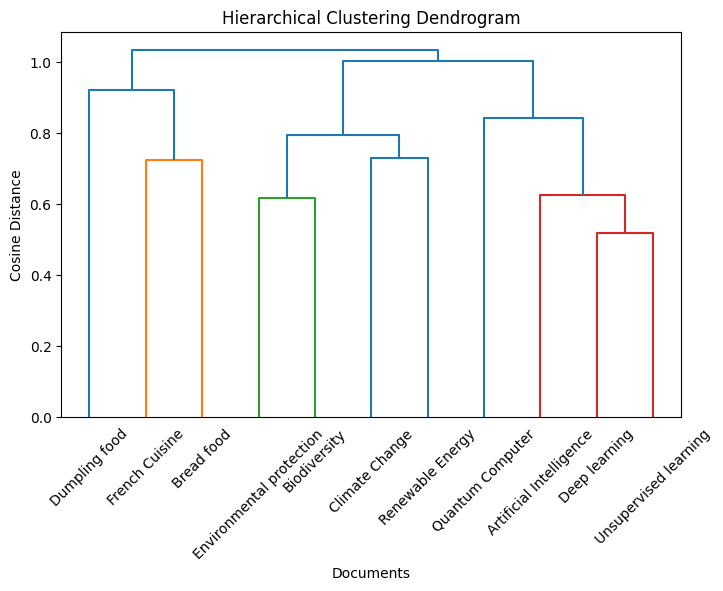

In [19]:
dist_matrix = pdist(emb_sent_df, metric='cosine')

Z = linkage(dist_matrix, method='complete')

plt.figure(figsize=(8,5))
dendrogram(Z, labels=wiki_df["wiki query"].values, leaf_rotation=45, leaf_font_size=10)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Documents")
plt.ylabel("Cosine Distance")
plt.show()

In [20]:
hier_emb_labels = fcluster(Z, t=3, criterion='maxclust')

In [21]:
wiki_df["emb_hierarchical"] = hier_emb_labels
wiki_df

,wiki query,text,n_words,bow_kmeans,emb_kmeans,emb_dbscan,emb_hierarchical
0,Artificial Intelligence,artificial intelligence ai is the capability of computational systems to perform tasks typically associated with human intelligence such as learning reasoning problem-solving perception and decision-making,25,1,2,0,3
1,Deep learning,in machine learning deep learning dl focuses on utilizing multilayered neural networks to perform tasks such as classification regression and representation learning,22,2,2,0,3
2,Unsupervised learning,in machine learning supervised learning sl is a type of machine learning paradigm where an algorithm learns to map input data to a specific output based on example input-output pairs,30,2,2,0,3
3,Quantum Computer,a quantum computer is a real or theoretical computer that exploits superposed and entangled states,15,1,2,0,3
4,Environmental protection,environmental protection or environment protection refers to the taking of measures to protecting the natural environment prevent pollution and maintain ecological balance,22,0,0,1,2
5,Climate Change,present-day climate change includes both global warming — the ongoing increase in global average temperature — and its wider effects on earth climate system,24,1,0,1,2
6,Renewable Energy,renewable energy also called green energy is energy made from renewable natural resources that are replenished on a human timescale,20,1,0,1,2
7,Biodiversity,biodiversity is the variability of life on earth,8,1,0,1,2
8,French Cuisine,french cuisine is the cooking traditions and practices of france,10,1,1,2,1
9,Bread food,bread is a baked food product made from water flour and often yeast,13,1,1,2,1


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

### 1.6 Discussion
rubric={reasoning}

<div class="alert alert-info">

**Your tasks:**

Reflect on and discuss the clustering results of the methods you explored in the previous exercises, focusing on the following points:    
- effect of input representation on clustering results

- whether the clustering results match with your intuitions and the challenges associated with getting the desired clustering results with each method

</div>

<div class="alert alert-warning">

Solution_1.6
    
</div>

_Points:_ 4

- The input representation strongly affected the clustering quality. Using a Bag-of-Words Model with KMeans only captured word frequency, so documents with similar vocabulary were grouped together but deeper semantic relationships were not captured. Sentence embeddings much better captured semantic meaning, with all clustering methods producing groups that more closely matched the expected topics (technology, environment, and food). 
- The results matched the intuitive answers from the first question perfectly. However, methods like DBSCAN required careful tuning of hyperparameters such as eps, and poor choices were leading to no clusters at all or everything being part of one cluster. K-Means was easier to apply but required specifying the number of clusters in advance which may not always be known. Hierarchical clustering produced the most useful answer in my opinion with further classification, as well as us being able to specify how many overall clusters were needed and then it producing the same answer we got from kMeans and DBSCAN. Overall, choosing an appropriate text representation and tuning hyperparameters were key challenges in obtaining meaningful clustering results.

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

### 1.7 Visualizing clusters
rubric={points:4}


One approach to working with unlabeled data is visualization. That said, our data is high-dimensional, making it challenging to visualize. Take sentence embedding representation as an example: each instance is depicted in 768 dimensions. To visualize such high-dimensional data, we can employ dimensionality reduction techniques to extract the most significant 2 or 3 components, and then visualize this low-dimensional data.

Given data as a `numpy` array and corresponding cluster assignments, the `plot_umap_clusters` function below transforms the data by applying dimensionality reduction technique called [UMAP](https://umap-learn.readthedocs.io/en/latest/) to it and plots the transformed data with different colours for different clusters. 

> *Note: At this point we are using this function only for visualization and you are not expected to understand the UMAP part.* 

You'll have to install the `umap-learn` package in the course conda environment either with `conda` or `pip`, as described in the [documentation](https://umap-learn.readthedocs.io/en/latest/index.html). 

```
> conda activate cpsc330
> conda install -c conda-forge umap-learn
```
or

```
> conda activate cpsc330
> pip install umap-learn 
```

If you get an error with the import below try

```
pip install --upgrade numba umap-learn
```

<div class="alert alert-info">
    
**Your tasks:**

1. Visualize the clusters created by the methods above using `plot_umap_clusters` function below. In other words, visualize clusters identified by each of the methods below. 
    - K-Means with bag-of-words representation 
    - K-Means with sentence embedding representation
    - DBSCAN with sentence embedding representation 
    - Flat cluster of hierarchical clustering with sentence embedding representation
</div>

In [31]:
import umap

In [32]:
def plot_umap_clusters(
    data,
    cluster_labels,
    raw_texts=None,
    show_labels=False,
    point_size=50,
    n_neighbors=15,
    title="UMAP Visualization",
    ignore_noise=False,
):
    """
    Perform dimensionality reduction using UMAP and visualize the resulting clusters.

    Parameters
    ----------
    data : np.ndarray
        Feature matrix to be reduced.
    cluster_labels : array-like
        Cluster label for each data point.
    raw_texts : list of str, optional
        Original texts corresponding to the data points (used when show_labels=True).
    show_labels : bool, default=False
        Whether to annotate points with text labels.
    point_size : int, default=50
        Size of the scatterplot points.
    n_neighbors : int, default=15
        Number of neighbors used in UMAP.
    title : str, default="UMAP Visualization"
        Title of the plot.
    ignore_noise : bool, default=False
        Whether to exclude points labeled as noise (-1).

    Returns
    -------
    None
    """
    reducer = umap.UMAP(n_neighbors=n_neighbors, random_state=42)
    embedding = reducer.fit_transform(data)

    df = pd.DataFrame(embedding, columns=["dim1", "dim2"])
    df["cluster"] = cluster_labels

    if ignore_noise:
        df = df[df["cluster"] != -1]

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.set_title(title)

    scatter = ax.scatter(
        df["dim1"], df["dim2"],
        c=df["cluster"], cmap="tab20b", s=point_size
    )

    ax.legend(*scatter.legend_elements(), title="Clusters", loc="best")

    if show_labels and raw_texts is not None:
        for (x, y, text) in zip(df["dim1"], df["dim2"], raw_texts):
            ax.annotate(" ".join(text.split()[:10]), (x, y), fontsize=8)

    plt.show()


<div class="alert alert-warning">

Solution_1.7
    
</div>

_Points:_ 4

c:\Users\kreet\Desktop\Files\UBC\Year 4\Term 2\CPSC 330\HW\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\kreet\Desktop\Files\UBC\Year 4\Term 2\CPSC 330\HW\venv\Lib\site-packages\umap\umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


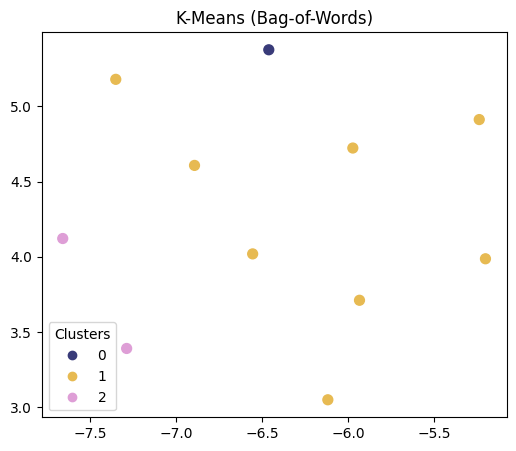

In [33]:
plot_umap_clusters(
    np.array(text_bow.toarray()),
    kmeans_bow_labels,
    raw_texts=wiki_df["text"],
    title="K-Means (Bag-of-Words)"
)

C:\Users\kreet\AppData\Local\Temp\ipykernel_35772\2652419284.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\kreet\AppData\Local\Temp\ipykernel_35772\2652419284.py:2460: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


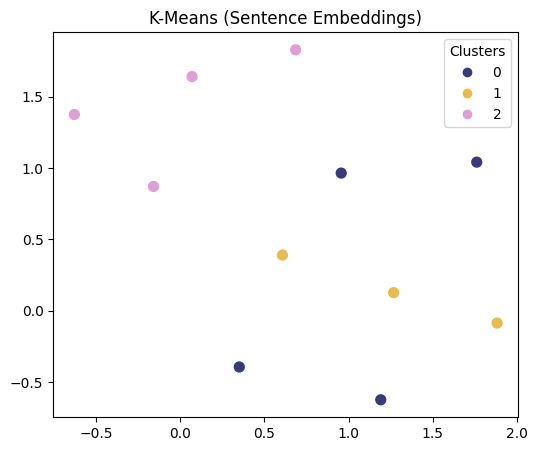

In [28]:
plot_umap_clusters(
    emb_sents,
    kmeans_emb_labels,
    raw_texts=wiki_df["text"],
    title="K-Means (Sentence Embeddings)"
)

c:\Users\kreet\Desktop\Files\UBC\Year 4\Term 2\CPSC 330\HW\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\kreet\Desktop\Files\UBC\Year 4\Term 2\CPSC 330\HW\venv\Lib\site-packages\umap\umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


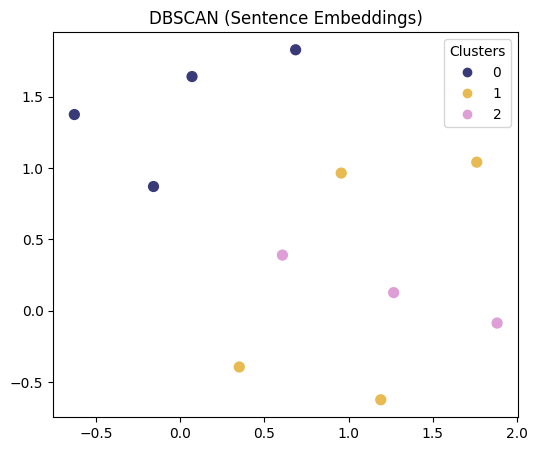

In [34]:
plot_umap_clusters(
    emb_sents,
    dbscan_emb_labels,
    raw_texts=wiki_df["text"],
    title="DBSCAN (Sentence Embeddings)",
    ignore_noise=True
)

C:\Users\kreet\AppData\Local\Temp\ipykernel_35772\2652419284.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\kreet\AppData\Local\Temp\ipykernel_35772\2652419284.py:2460: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


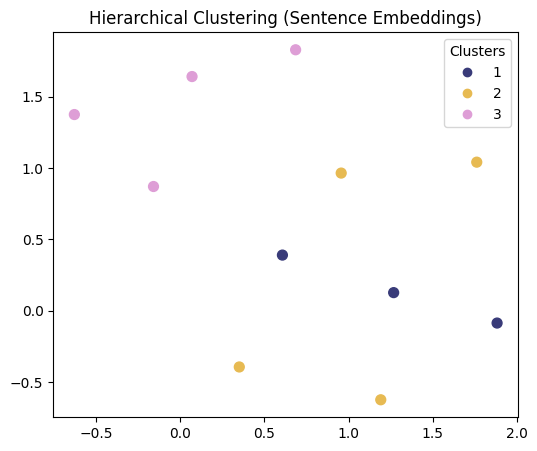

In [30]:
plot_umap_clusters(
    emb_sents,
    hier_emb_labels,
    raw_texts=wiki_df["text"],
    title="Hierarchical Clustering (Sentence Embeddings)"
)

<!-- END QUESTION -->

<br><br><br><br>

## Exercise 2: [Food.com](https://www.food.com/) recipes 
<hr>

Now that we have applied document clustering on a toy corpus, let's move to a more realistic corpus. 

In the lecture, we worked on an activity of manually clustering food items and discussed challenges associated with it. We also applied different clustering algorithms to cluster food images. We'll continue this theme of clustering food items in this lab. But instead of images we will cluster textual description of food items, i.e., recipe names.   

In this assignment, we will work with a sample of [Kaggle's Food.com recipes corpus](https://www.kaggle.com/shuyangli94/food-com-recipes-and-user-interactions). This corpus contains 180K+ recipes and 700K+ recipe reviews. In this lab, we'll only focus on recipes and **not** on reviews. The recipes are present in `RAW_recipes.csv`. Our goal is to find categories or groupings of recipes from this corpus based on their names. 

**Your tasks:**

- Download [`RAW_recipes.csv`](https://www.kaggle.com/shuyangli94/food-com-recipes-and-user-interactions?select=RAW_recipes.csv) and put it under the `data` directory in the homework folder. 
- Run the code below. The dataset is quite large, and in this assignment, for speed, you will work with a sample of the dataset. The function `get_recipes_sample` below carries out some preliminary preprocessing and returns a sample of the recipes with most frequent tags. 

> *Note: Depending upon the capacity of your computer, feel free to increase or decrease the size of this sample by changing the value for `n_tags`. If you decide to go with a different value of `n_tags`, state it clearly in Exercise 2.1 so that the grader knows about it.* 

In [36]:
orig_recipes_df = pd.read_csv("data/RAW_recipes.csv")
orig_recipes_df.shape

(231637, 12)

In [37]:
def get_recipes_sample(orig_recipes_df, n_tags=300, min_len=5):
    orig_recipes_df = orig_recipes_df.dropna()  # Remove rows with NaNs.
    orig_recipes_df = orig_recipes_df.drop_duplicates(
        "name"
    )  # Remove rows with duplicate names.
    # Remove rows where recipe names are too short (< 5 characters).
    orig_recipes_df = orig_recipes_df[orig_recipes_df["name"].apply(len) >= min_len]
    # Only consider the rows where tags are one of the most frequent n tags.
    first_n = orig_recipes_df["tags"].value_counts()[0:n_tags].index.tolist()
    recipes_df = orig_recipes_df[orig_recipes_df["tags"].isin(first_n)]
    return recipes_df

In [38]:
recipes_df = get_recipes_sample(orig_recipes_df)
recipes_df.shape

(9100, 12)

In [39]:
recipes_df["name"]

42        i yam what i yam  muffins    
101       to your health  muffins      
129       250 00 chocolate chip cookies
138       lplermagronen                
163       california roll   salad      
                   ...                 
231514    zucchini blueberry bread     
231539    zucchini parmesan pancakes   
231547    zucchini salsa burgers       
231596    zuppa toscana                
231629    zydeco salad                 
Name: name, Length: 9100, dtype: str

<br><br>

**In the rest of the homework, we will use `recipes_df` above, which is a subset of the original dataset.** 

<br><br>

<!-- BEGIN QUESTION -->

<div class="alert alert-info">
    
### 2.1 Longest and shorter recipe names 
rubric={points:2}

**Your tasks:**

1. Print the shortest and longest recipe names (length in terms of number of characters) from `recipes_df`. If there is more than one recipe with the same shortest/longest length, store **one** of them in `shortest_recipe` and/or `longest_recipe` as a **string**.

</div>

<div class="alert alert-warning">

Solution_2.1
    
</div>

_Points:_ 2

In [40]:
recipes_df["name_length"] = recipes_df["name"].str.len()
shortest_recipe = recipes_df.loc[recipes_df["name_length"].idxmin(), "name"]
longest_recipe = recipes_df.loc[recipes_df["name_length"].idxmax(), "name"]

In [41]:
shortest_recipe

'bread'

In [42]:
longest_recipe

'baked tomatoes with a parmesan cheese crust and balsamic drizzle'

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

<div class="alert alert-info">
    
### 2.2 More EDA
rubric={points:2}

**Your tasks:**
1. Create a word cloud for the recipe names. You can use [the `wordcloud` package](https://github.com/amueller/word_cloud) for this, which you will have to install in the course environment.
```
> conda activate cpsc330
> conda install -c conda-forge wordcloud
```

</div>

<div class="alert alert-warning">

Solution_2.2
    
</div>

_Points:_ 2

In [43]:
from wordcloud import WordCloud

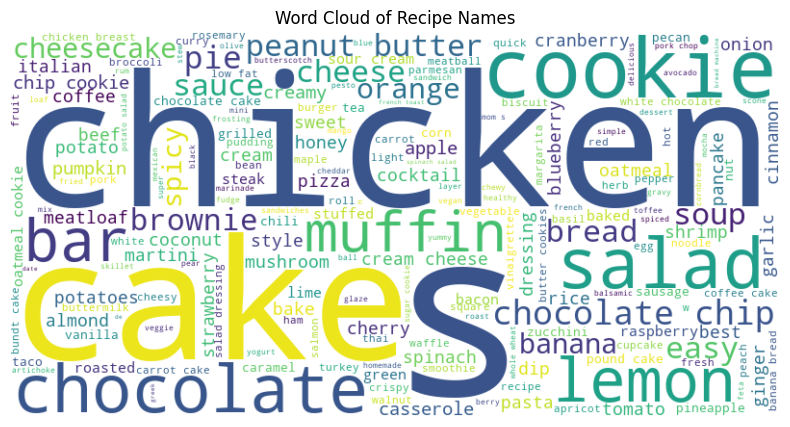

In [44]:
text = " ".join(recipes_df["name"].dropna())

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Recipe Names")
plt.show()

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

<div class="alert alert-info">

### 2.3 Representing recipe names
rubric={points:3}

The next step is creating a representation of recipe names. 

**Your tasks:**

1. Similar to Exercise 1, create sentence embedding representation of recipe names (`name` column in `recipes_df`).  For the rest of the homework, we'll stick to the sentence embedding representation of recipe names.


> You might have to convert the recipe names to a list (`recipes_df["name"].tolist()`) for the embedder to work
> *If you create a dataframe with sentence embedding representation, set the index to `recipes_df.index` so that the indices match with the indices of the sample we are working with.*  
> **This might take a while to run.**

</div>

<div class="alert alert-warning">

Solution_2.3
    
</div>

_Points:_ 3

In [50]:
recipe_emb_sents = embedder.encode(recipes_df["name"].tolist(), convert_to_tensor=True)
embeddings = pd.DataFrame(recipe_emb_sents, index=recipes_df.index)

<!-- END QUESTION -->

<br><br><br><br>

## Exercise 3: Clustering recipe names
<hr>

In this exercise you'll cluster recipe names with some of the clustering algorithms we have seen in class. This will also involve making some attempts to pick reasonable hyperparameter values for each clustering method based on the quality of the resulting clusters. For example, for KMeans, you need to specify the number of clusters in advance, which is often challenging on real-world datasets. For DBSCAN, you need to pick appropriate `eps` and `min_samples`. For hierarchical clustering, you need to pick a suitable linkage criterion, distance metric, and prune the tree so that it's possible to visualize and interpret it. 

Here are some methods which may help you with picking reasonable values for the hyperparameters. 
- Visualize the Elbow plot (KMeans). 
- Visualize Silhouette plots. 
- Visualize resulting clusters using `plot_umap_clusters` function from Exercise 1. 
- Sample some recipes from each cluster, manually inspect whether there are coherent semantic themes. (For this, you may use the function `print_clusters` given below.) 
        
> You may use the [`yellowbrick`](https://www.scikit-yb.org/en/latest/) package for visualizing the Elbow plot and the Silhouette plots. You can intall it with

```conda install -c districtdatalabs yellowbrick```

**Note that the process of picking reasonable hyperparameter values will be exploratory, iterative, and will involve manual inspection and judgment, as there is no ground truth to verify how well the model is doing. In your solutions, please do not include everything you try. Only present the results of the most informative trials. Add a narrative to your answer so that it's easy for the grader to follow your choices and reasoning.** 

In [51]:
def print_clusters(recipes_df, cluster_labels, n_recipes=10, replace=False, random_state=None):
    """
    Given recipes_df containing recipe names and cluster assignment (labels), 
    sample and print n_recipes recipes per cluster. 

    Parameters
    -----------
    recipe_df : pandas dataframe 
        recipes dataframe containing recipe names in the "name" column
    cluster_labels : ndarray or a list
        cluster labels for each row in recipes_df 
    n_recipes : int
        number of examples to sample from each cluster
    replace: bool
        replace flag to pass to the sampling of recipe names

    Returns
    -----------
    None
    """    
    
    grouped = (
        pd.DataFrame(
            {
                "name": recipes_df["name"],
                "cluster_label": cluster_labels,
            }
        )
        .sort_values("cluster_label")
        .groupby("cluster_label")    
    )
    
    for name, group in grouped:
        print(f"Cluster {name}")        
        print(("----------").format(""))        
        print("\n".join(group.sample(n_recipes, random_state=random_state, replace=replace)['name'].tolist()))
        print("\n\n")

<br><br>

<!-- BEGIN QUESTION -->

<div class="alert alert-info">
    
### 3.1 K-Means
rubric={points:6}

**Your tasks:**

1. Cluster recipe titles using KMeans. Make some attempts to determine the optimal number of clusters. 
2. Pick one or two best models and justify your choice.

</div>

<div class="alert alert-warning">

Solution_3.1
    
</div>

_Points:_ 6

### Choice Justification

I ended up choosing k=4 despite KElbowVisualizer suggesting k=8 being where the elbow is, as by visual inspection, the distortion score score plot does not seem to have a clear elbow, with k in [4, 6, 8, 9, 12] each having a sudden flatter bend and thus I relied more strongly on the silhouette plots. In the silhouette plots, we observe that only for k=4 do we have most clusters extending well beyond the average silhouette score while still having some breadth, with the exception of one (red) cluster that has a strong negative tail and a head that barely crosses the average silhouette score. 

For k=6, we have a lot of variation in plot size with two clusters having strong negative tails and much sharper heads for 3/6 clusters. For k=8, we see that 4/8 clusters do not extend properly beyond the average silhouette score. k=12 is likely the best runner up choice, though it has sharp heads and 2 clusters that have strong negative ends and a lot of variation in cluster size.

In [55]:
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

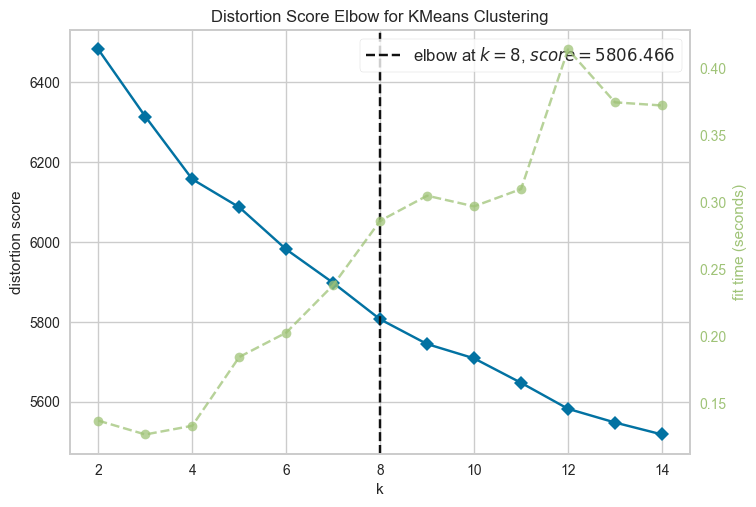

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [54]:
model = KMeans(random_state=123)

visualizer = KElbowVisualizer(model, k=(2,15), force_model=True)
visualizer.fit(embeddings)
visualizer.show()

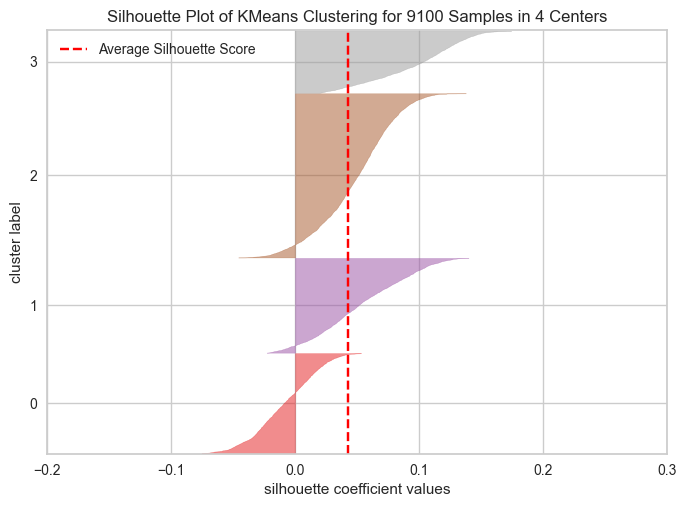

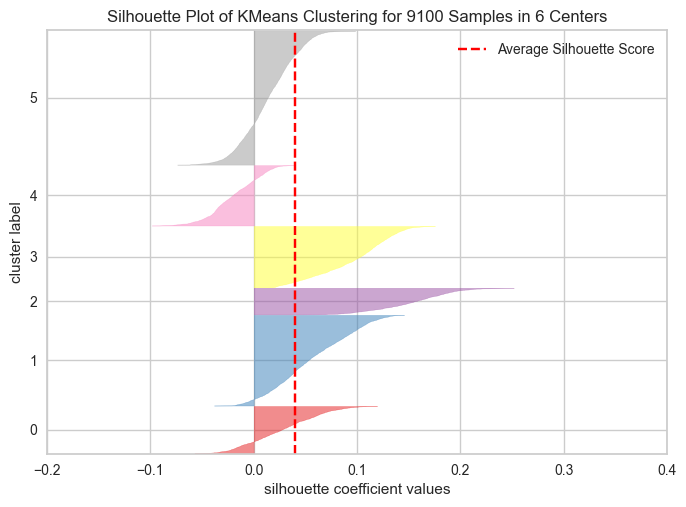

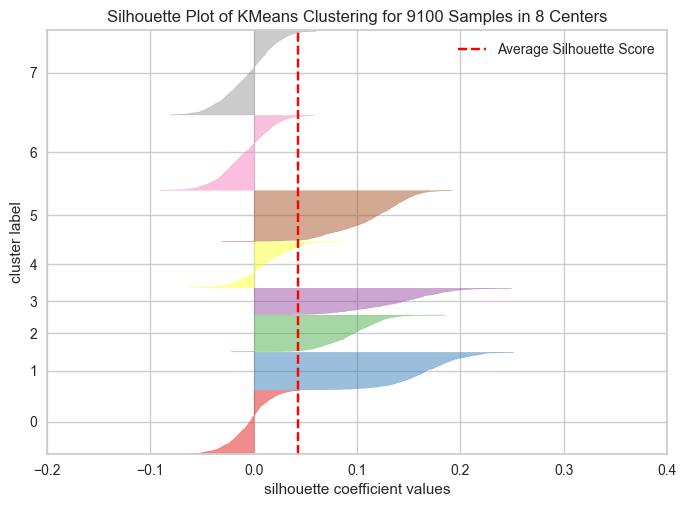

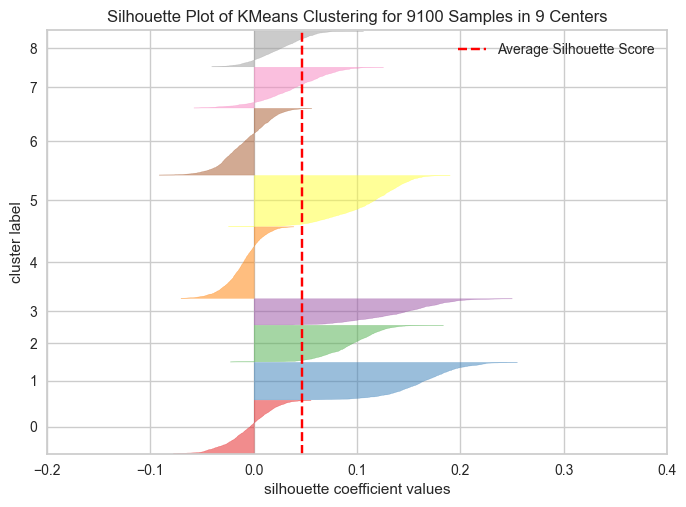

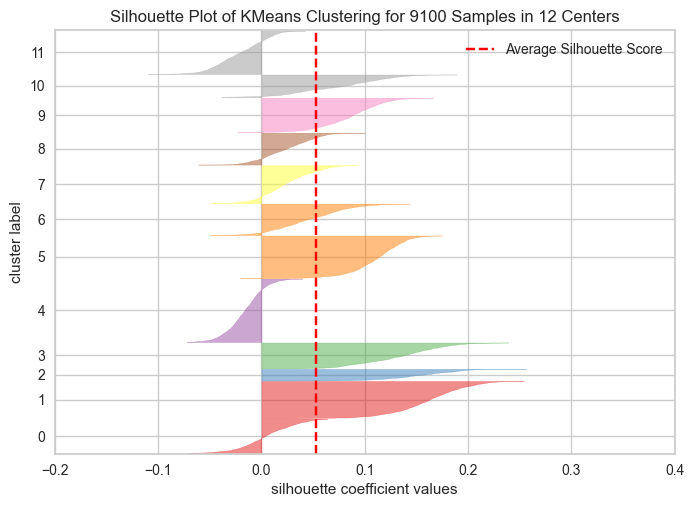

In [65]:
for n in [4, 6, 8, 9, 12]:
    model = KMeans(n_clusters=n, random_state=123)
    visualizer = SilhouetteVisualizer(model, force_model=True)

    visualizer.fit(embeddings)
    visualizer.show()

In [68]:
kmeans = KMeans(n_clusters=4, random_state=123)
recipes_df["cluster"] = kmeans.fit_predict(embeddings)

<!-- END QUESTION -->

<br><br><br><br>

<!-- BEGIN QUESTION -->

<div class="alert alert-info">
    
### 3.2 DBSCAN
rubric={points:6}

**Your tasks:**

1. Cluster recipe names using `DBSCAN` with `metric="cosine"`. Make some attempts to tune the  hyperparameters `eps` and `min_samples`.

</div>

<div class="alert alert-warning">

Solution_3.2
    
</div>

_Points:_ 6

_Type your answer here, replacing this text._

In [69]:
dist_matrix = cosine_distances(embeddings)

print("Min distance:", np.min(dist_matrix))
print("Max distance:", np.max(dist_matrix))
print("Mean distance:", np.mean(dist_matrix))

Min distance: 0.0
Max distance: 1.2340795
Mean distance: 0.7506512


In [107]:
for eps in [0.1, 0.12, 0.14, 0.16, 0.18, 0.2, 0.22, 0.24]:
    dbscan = DBSCAN(eps=eps, min_samples=15, metric='cosine')
    labels = dbscan.fit_predict(embeddings)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    print(f"eps={eps} -> clusters={n_clusters}, labels={labels}")

eps=0.1 -> clusters=0, labels=[-1 -1 -1 ... -1 -1 -1]
eps=0.12 -> clusters=1, labels=[-1 -1 -1 ... -1 -1 -1]
eps=0.14 -> clusters=1, labels=[-1 -1 -1 ... -1 -1 -1]
eps=0.16 -> clusters=2, labels=[-1 -1 -1 ... -1 -1 -1]
eps=0.18 -> clusters=3, labels=[-1 -1 -1 ... -1 -1 -1]
eps=0.2 -> clusters=6, labels=[-1 -1 -1 ... -1 -1 -1]
eps=0.22 -> clusters=5, labels=[-1 -1 -1 ... -1 -1 -1]
eps=0.24 -> clusters=11, labels=[-1 -1  1 ... -1 -1 -1]


In [112]:
dbscan = DBSCAN(eps=0.22, min_samples=15, metric='cosine')
dbscan_emb_labels = dbscan.fit_predict(emb_sents)
recipes_df["dbscan_cluster"] = dbscan.fit_predict(emb_sents)
dbscan_emb_labels

array([-1, -1, -1, ..., -1, -1, -1], shape=(9100,))

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

<div class="alert alert-info">
    
### 3.3 Hierarchical clustering
rubric={points:6}

**Your tasks:**

1. Try hierarchical clustering with `metric="cosine"` on this problem. Show a dendrogram by using a suitable truncation method. 
2. Create flat clusters by cutting the tree at the appropriate level. 

> *Note: Try orientation="left" of `dendrogram` for better readability of the dendrogram.*

</div>

<div class="alert alert-warning">

Solution_3.3
    
</div>

_Points:_ 6

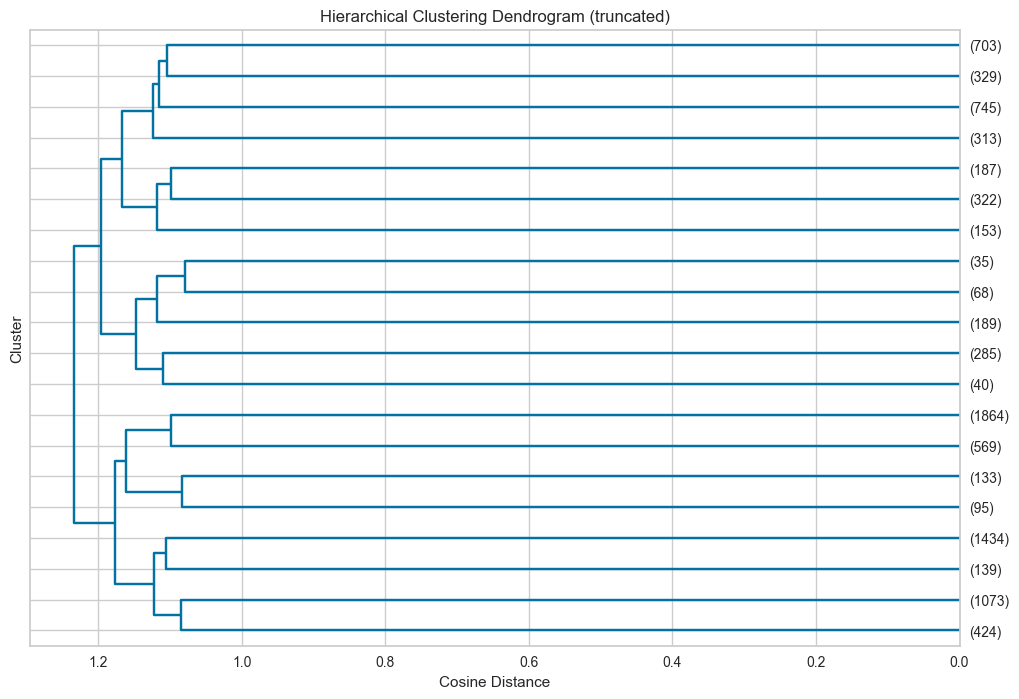

In [76]:
dist_matrix = pdist(embeddings, metric='cosine')

Z = linkage(dist_matrix, method='complete')

plt.figure(figsize=(12, 8))

dendro = dendrogram(
    Z,
    truncate_mode="lastp",
    p=20,
    leaf_rotation=0,
    leaf_font_size=10,
    orientation="left",
    color_threshold=0.7
)

plt.title("Hierarchical Clustering Dendrogram (truncated)")
plt.xlabel("Cosine Distance")
plt.ylabel("Cluster")
plt.show()

In [78]:
recipes_df["hier_cluster"] = fcluster(Z, t=4, criterion="maxclust")

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

<div class="alert alert-info">
    
### 3.4 Manual interpretation of clusters
rubric={points:6}

**Your tasks:**

1. Label the topics/themes you see in the clusters created by different clustering methods.  
2. Do you see a common theme across clusters created by different clustering methods? Do you see any differences between the clusters created by different clustering methods?

</div>

<div class="alert alert-warning">

Solution_3.4
    
</div>

_Points:_ 6

### Labelling topics/themes

For KMeans clustering, we see cluster 0 as being more so related to party foods or snacks, cluster 1 being sweets and bread, cluster 2 being more like actual meals, and cluster 3 being mostly desserts and baked snacks.

For DBSCAN, we know that cluster -1 was seen as noise, and we can notice that cluster 0 very clearly corresponds to salads based on the random results viewed, cluster 1 seems to be all about cookies, cluster 2 is all carrot cake related, cluster 3 is lemon cake related, and cluster 4 is snickerdoodles related. This is slightly surprising because one would imagine that most foods then ended up in cluster -1, but we do see very clear themes compared to those produced by Kmeans.

For fcluster, we see a little mixing similar to KMeans, with cluster 1 being savory dishes, cluster 2 being smaller dishes and some baked goods, cluster 3 being more experimental novelty items, and cluster 4 being desserts and drinks.


### Common themes

A common theme across all clustering methods is that desserts and baked goods consistently form distinct clusters. Savory meals, like salads and main courses, also appear as clusters but are often broader or less coherent. DBSCAN produces very specific dessert clusters and treats many other recipes as noise, while KMeans and hierarchical clustering create larger, more general clusters. Overall, all methods capture similar broad categories, but DBSCAN is more precise and conservative, whereas KMeans and hierarchical group more diverse recipes together.


In [85]:
def sample_cluster_items(df, cluster_col, name_col, n=5):
    clusters = df[cluster_col].unique()
    for c in sorted(clusters):
        print(f"\nCluster {c}:")
        sample = df[df[cluster_col] == c][name_col].sample(n=min(n, len(df[df[cluster_col] == c])), random_state=42)
        for i, item in enumerate(sample, 1):
            print(f"  {i}. {item}")

In [86]:
sample_cluster_items(recipes_df, "cluster", "name", n=5)


Cluster 0:
  1. very addicting chex mix
  2. randy s remoulade sauce
  3. party dream squares
  4. liquid oreos
  5. pink skyy

Cluster 1:
  1. peaches and cream muffins
  2. crescent roll pastry
  3. aunt sharon s best brownies
  4. subway bread copycat
  5. soft   chewy sugar cookies

Cluster 2:
  1. beer butt chicken   beer can
  2. ranch meatloaf
  3. strawberries with salad greens and poppy seed dressing
  4. perfect ham and bean soup
  5. everyday meatloaf

Cluster 3:
  1. malted milk ball cupcakes
  2. gateau basque  french pastry cream version
  3. go big red cake
  4. david s carrot cake
  5. cheesy potato bake


In [113]:
sample_cluster_items(recipes_df, "dbscan_cluster", "name", n=5)


Cluster -1:
  1. skinny french fry dipping sauce
  2. sourdough oatmeal muffins
  3. magical low calorie margarita
  4. chunky mashed potatoes
  5. bbq ham caesar salad

Cluster 0:
  1. feta and red onion spinach salad
  2. chef salad  dressing
  3. spinach and salmon salad
  4. asian spinach salad with orange and avocado
  5. spinach cranberry salad

Cluster 1:
  1. joy of cooking s oatmeal cookies
  2. betty s banana chocolate chunk cookies
  3. low fat  high fiber oatmeal raisin cookies
  4. chocolate filled oatmeal bars
  5. cherry cream cheese cookies

Cluster 2:
  1. beet and carrot cake
  2. nuttier carrot cake
  3. fruit and carrot cake
  4. best ever carrot cake
  5. orange carrot cake ii

Cluster 3:
  1. almond lemon cake
  2. glazed lemon buttermilk pound cake
  3. lemon cake with lemon filling and lemon butter frosting
  4. sour cream lemon cake
  5. luscious lemon cake

Cluster 4:
  1. snickerdoodles
  2. soft  n chewy snickerdoodles
  3. apple snickerdoodles
  4. toffee 

In [114]:
sample_cluster_items(recipes_df, "hier_cluster", "name", n=5)


Cluster 1:
  1. italian pizza sandwiches
  2. spinach and tangerine salad
  3. low fat sesame orange dressing
  4. balsamic orange couscous
  5. best beef tips and gravy

Cluster 2:
  1. persian butter cookies
  2. authentic southern fried okra
  3. gooey mandarin cake
  4. mincemeat bread
  5. kart wheels

Cluster 3:
  1. bailey s brownies
  2. twisted snow pea toss
  3. blizzard
  4. jet ski killer
  5. calamari fra diavolo over linguine

Cluster 4:
  1. jammin  almond bars
  2. caramel chocolate chip bars
  3. butter chocolate bliss martini
  4. blueberry cheese bars
  5. top secret recipes version of doubletree hotel chocolate chip co


<!-- END QUESTION -->

<br><br><br><br>

Before submitting your assignment, please make sure you have followed all the instructions in the Submission Instructions section at the top. 

Here is a quick checklist before submitting: 

- [ ] Restart kernel, clear outputs, and run all cells from top to bottom.  
- [ ] `.ipynb` file runs without errors and contains all outputs.  
- [ ] Only `.ipynb` and required output files are uploaded (no extra files).  
- [ ] Execution numbers start at **1** and are in order.  
- [ ] If `.ipynb` is too large and doesn't render on Gradescope, also upload a PDF/HTML version.  
- [ ] Reviewed the [CPSC 330 homework instructions](https://ubc-cs.github.io/cpsc330-2025W2/docs/homework-instructions).

![](img/eva-well-done.png)